# Systematics 1D Four-Point Ratio Test

This notebook keeps the independent Falkon density-ratio strategy, but replaces the single symmetric pair used for each Taylor coefficient with the four nuisance values used in the NN paper.

For every training value $\nu_i$, an independent model estimates

$$
\widehat g_i(x) = \widehat{\log r}(x;\nu_i).
$$

The coefficients are then obtained at each $x$ from a zero-intercept polynomial fit,

$$
\widehat g_i(x) \simeq \nu_i\,\widehat\delta_1(x) + \frac{\nu_i^2}{2}\,\widehat\delta_2(x).
$$

The linear fit uses $\nu=\{\pm0.05,\pm0.1\}$ and the quadratic fit uses $\nu=\{\pm0.2,\pm0.3\}$. The two fits have no shared nuisance points, so eight Falkon models are trained in total.

In [33]:
from pathlib import Path
import sys
import time

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "examples":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

from nplm_systematics import FalkonLogRatioEstimator
from nplm_systematics.morphing import QuadraticLogRMorphingCache
from nplm_systematics.toys import (
    paper_exponential_bin_log_ratio,
    paper_exponential_delta1,
    paper_exponential_delta2,
    paper_exponential_log_ratio,
    sample_paper_exponential_nuisance,
)

plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True})

## Configuration

The central and each nuisance-varied auxiliary sample contain 20000 events. The scale settings follow the NN `expo1D` example: `scale_REF = 1` and `scale_DATA = 1.03`. The separate `n_data` sample is used only by the cache demonstration.

When `sigma=None`, one median-heuristic bandwidth is estimated from the union of all central and varied samples and reused in every Falkon fit. This avoids introducing a different kernel scale for each nuisance point.

In [50]:
seed = 123
rng = np.random.default_rng(seed)

scale_ref = 1.0
scale_data = 1.03
nu_data = np.log(scale_data / scale_ref)
sigma_nuisance = 0.1

n_central = 20_000
n_varied = 20_000
n_data = 5_000

linear_nu_values = np.array([-0.1, -0.15, 0.15, 0.1], dtype=np.float64)
quadratic_nu_values = np.array([-0.3, -0.2, 0.2, 0.3], dtype=np.float64)
training_nu_values = np.unique(np.concatenate([linear_nu_values, quadratic_nu_values]))

x_plot_max = 6.0
grid = np.linspace(0.0, x_plot_max, 250, dtype=np.float64).reshape(-1, 1)

ratio_config = {
    "sigma": 4,
    "M": 5_000,
    "lambda": [1e-10],
    "iter": [100000],
    "cg_tol": np.sqrt(1e-7),
    "keops": "yes",
    "cpu": False,
    "seed": seed,
    "verbose": 0,
}

{
    "nu_data": nu_data,
    "sigma_nuisance": sigma_nuisance,
    "n_central": n_central,
    "n_varied_per_nuisance_sample": n_varied,
    "linear_nu_values": linear_nu_values,
    "quadratic_nu_values": quadratic_nu_values,
}

{'nu_data': 0.029558802241544425,
 'sigma_nuisance': 0.1,
 'n_central': 20000,
 'n_varied_per_nuisance_sample': 20000,
 'linear_nu_values': array([-0.1 , -0.15,  0.15,  0.1 ]),
 'quadratic_nu_values': array([-0.3, -0.2,  0.2,  0.3])}

## Generate the Samples

All ratio estimators use the same central sample. The varied samples contain shape changes only, so every fit uses `target_norm_ratio=1`.

In [51]:
x_central = sample_paper_exponential_nuisance(
    n_central, 0.0, rng=rng
).reshape(-1, 1)
x_data = sample_paper_exponential_nuisance(
    n_data, nu_data, rng=rng
).reshape(-1, 1)
varied_samples = {
    float(nu): sample_paper_exponential_nuisance(
        n_varied, float(nu), rng=rng
    ).reshape(-1, 1)
    for nu in training_nu_values
}

{nu: sample.shape for nu, sample in varied_samples.items()}

{-0.3: (20000, 1),
 -0.2: (20000, 1),
 -0.15: (20000, 1),
 -0.1: (20000, 1),
 0.1: (20000, 1),
 0.15: (20000, 1),
 0.2: (20000, 1),
 0.3: (20000, 1)}

## Train Eight Independent Falkon Ratios

The models estimate $g_\nu(x)=\log[p(x\mid\nu)/p(x\mid0)]$. Training remains independent across nuisance values; the polynomial structure is imposed only when their predictions are combined.

In [52]:
fit_config = dict(ratio_config)
if fit_config["sigma"] is None:
    fit_config["sigma"] = FalkonLogRatioEstimator.estimate_sigma_median(
        np.vstack([x_central] + list(varied_samples.values())),
        seed=seed,
    )

ratio_models = {}
fit_times = {}
for nu in training_nu_values:
    nu = float(nu)
    estimator = FalkonLogRatioEstimator(fit_config)
    start = time.time()
    estimator.fit(
        x_central,
        varied_samples[nu],
        target_norm_ratio=1.0,
    )
    ratio_models[nu] = estimator
    fit_times[nu] = time.time() - start
    print(f"nu={nu:+.2f}: {fit_times[nu]:.1f} s")

{"sigma": fit_config["sigma"], "fit_times": fit_times}

Iteration 0 - penalty 1.000000e-10 - sub-iterations 100000
nu=-0.30: 2.3 s
Iteration 0 - penalty 1.000000e-10 - sub-iterations 100000
nu=-0.20: 1.6 s
Iteration 0 - penalty 1.000000e-10 - sub-iterations 100000
nu=-0.15: 1.5 s
Iteration 0 - penalty 1.000000e-10 - sub-iterations 100000
nu=-0.10: 2.2 s
Iteration 0 - penalty 1.000000e-10 - sub-iterations 100000
nu=+0.10: 1.9 s
Iteration 0 - penalty 1.000000e-10 - sub-iterations 100000
nu=+0.15: 2.1 s
Iteration 0 - penalty 1.000000e-10 - sub-iterations 100000
nu=+0.20: 2.3 s
Iteration 0 - penalty 1.000000e-10 - sub-iterations 100000
nu=+0.30: 2.2 s


{'sigma': 4,
 'fit_times': {-0.3: 2.2714760303497314,
  -0.2: 1.6366734504699707,
  -0.15: 1.5415239334106445,
  -0.1: 2.1552085876464844,
  0.1: 1.9050278663635254,
  0.15: 2.14982008934021,
  0.2: 2.313735246658325,
  0.3: 2.1840784549713135}}

## Fit the Taylor Coefficients

For nuisance values $\nu_i$, define the quadratic design matrix

$$
A_i = \begin{pmatrix}\nu_i & \nu_i^2/2\end{pmatrix}.
$$

At every evaluation point, the coefficients are

$$
\begin{pmatrix}\widehat\delta_1(x) \\ \widehat\delta_2(x)\end{pmatrix}
= (A^T A)^{-1}A^T\widehat{\mathbf g}(x).
$$

No intercept is included because $g(x;0)=0$. Symmetric nuisance values make the odd and even columns orthogonal.

In [53]:
def predict_ratio_models(models, x):
    """Evaluate every nuisance-point ratio model on one sample.

    :param models: Mapping from nuisance values to fitted estimators.
    :param x: Evaluation sample with shape ``(n_samples, n_features)``.
    :returns: Mapping from nuisance values to prediction arrays.
    """
    return {nu: model.predict_log_ratio(x) for nu, model in models.items()}


def fit_taylor_coefficients(predictions, nuisance_values, order):
    """Fit zero-intercept Taylor coefficients to ratio predictions.

    :param predictions: Mapping from nuisance values to arrays with shape ``(n_samples,)``.
    :param nuisance_values: Nuisance values included in the fit.
    :param order: Polynomial order, either one or two.
    :returns: Coefficient array with shape ``(order, n_samples)``.
    """
    nuisance_values = np.asarray(nuisance_values, dtype=np.float64).reshape(-1)
    if order not in (1, 2):
        raise ValueError("order must be one or two")
    if nuisance_values.size < order:
        raise ValueError("not enough nuisance values for the requested order")

    response = np.vstack([predictions[float(nu)] for nu in nuisance_values])
    columns = [nuisance_values]
    if order == 2:
        columns.append(0.5 * nuisance_values**2)
    design = np.column_stack(columns)
    return np.linalg.lstsq(design, response, rcond=None)[0]


grid_predictions = predict_ratio_models(ratio_models, grid)
central_predictions = predict_ratio_models(ratio_models, x_central)
data_predictions = predict_ratio_models(ratio_models, x_data)

linear_grid_coefficients = fit_taylor_coefficients(
    grid_predictions, linear_nu_values, order=1
)
linear_central_coefficients = fit_taylor_coefficients(
    central_predictions, linear_nu_values, order=1
)
linear_data_coefficients = fit_taylor_coefficients(
    data_predictions, linear_nu_values, order=1
)
quadratic_grid_coefficients = fit_taylor_coefficients(
    grid_predictions, quadratic_nu_values, order=2
)
quadratic_central_coefficients = fit_taylor_coefficients(
    central_predictions, quadratic_nu_values, order=2
)
quadratic_data_coefficients = fit_taylor_coefficients(
    data_predictions, quadratic_nu_values, order=2
)

delta1_linear_grid = linear_grid_coefficients[0]
delta1_quadratic_grid = quadratic_grid_coefficients[0]
delta2_quadratic_grid = quadratic_grid_coefficients[1]

## Check the Eight Learned Ratios

This separates failures of an individual Falkon ratio fit from failures introduced by the polynomial combination.

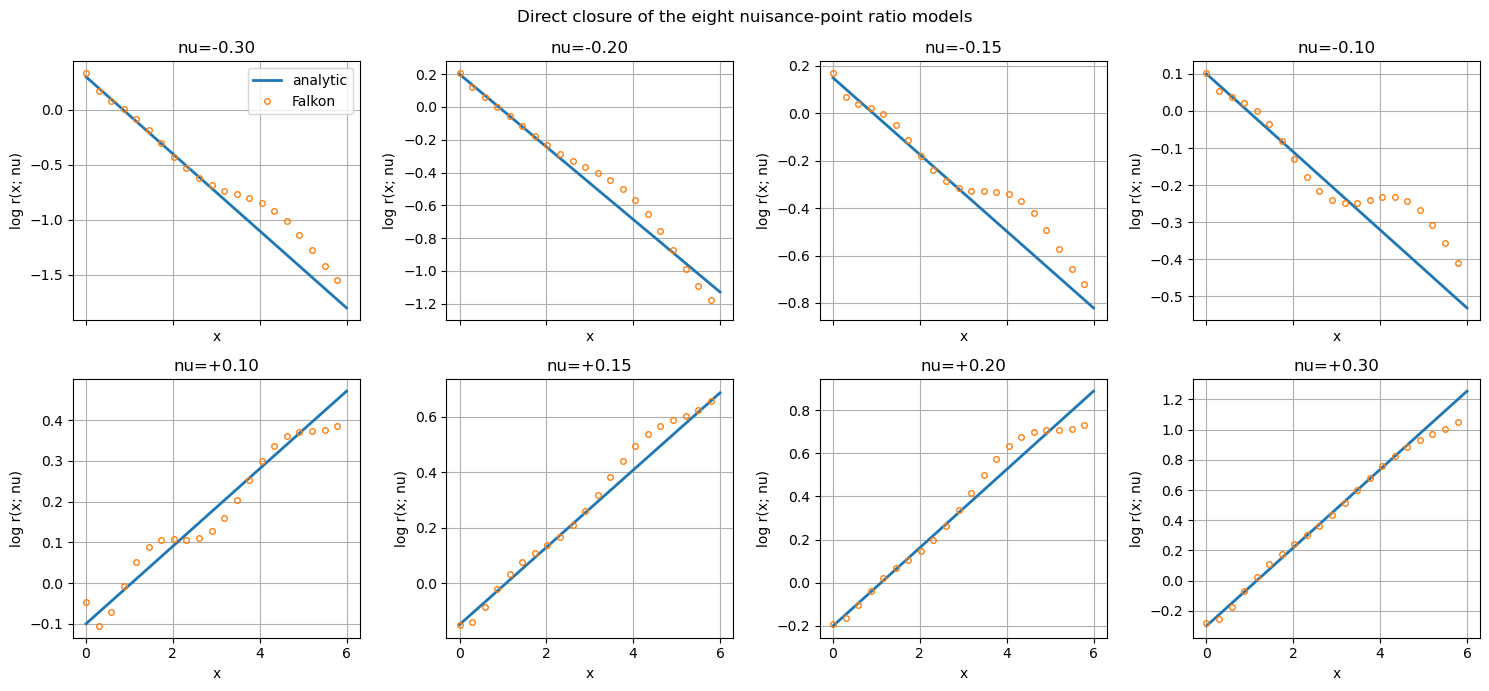

In [54]:
x_flat = grid.reshape(-1)
fig, axes = plt.subplots(2, 4, figsize=(15, 7), sharex=True)

for ax, nu in zip(axes.reshape(-1), training_nu_values):
    nu = float(nu)
    ax.plot(x_flat, paper_exponential_log_ratio(x_flat, nu), lw=2, label="analytic")
    ax.plot(
        x_flat,
        grid_predictions[nu],
        "o",
        fillstyle="none",
        markevery=12,
        ms=4,
        label="Falkon",
    )
    ax.set_title(f"nu={nu:+.2f}")
    ax.set_xlabel("x")
    ax.set_ylabel("log r(x; nu)")

axes[0, 0].legend()
fig.suptitle("Direct closure of the eight nuisance-point ratio models")
fig.tight_layout();

## Inspect the Quadratic Pair Estimates

Before combining the two quadratic pairs, inspect their even components separately:

$$
E_h(x)=\frac{\widehat g(x;+h)+\widehat g(x;-h)}{h^2}.
$$

The learned $E_h$ is compared with the exact finite-step quantity and with the Taylor coefficient $\delta_2(x)=-x$. The exact finite-step curve differs slightly from $\delta_2$ through higher even orders, but both must vanish at $x=0$.

{'E_0.2_at_x0': 0.40842828848326457, 'E_0.3_at_x0': 0.6310885559691491, 'E_0.2_rmse_to_finite_exact': 3.078212274308878, 'E_0.3_rmse_to_finite_exact': 1.606219643237043}


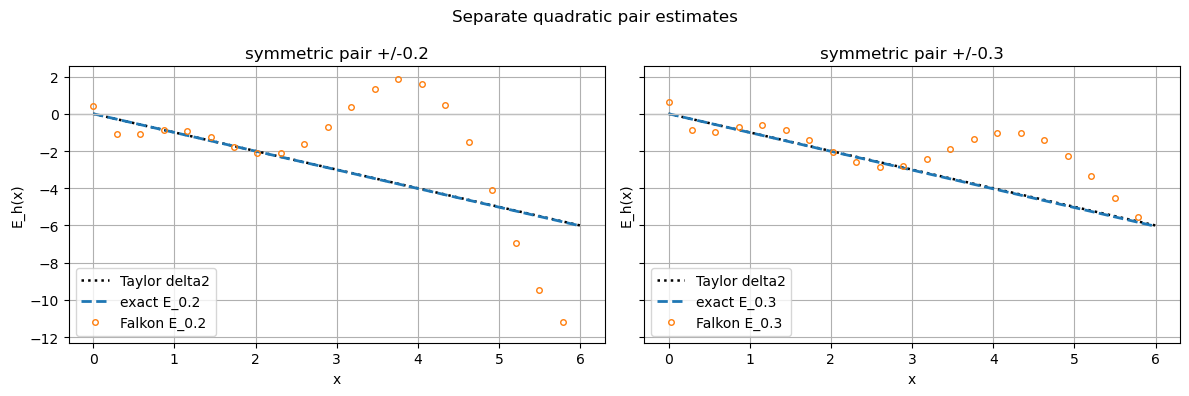

In [55]:
quadratic_step_values = np.unique(np.abs(quadratic_nu_values))
delta2_analytic = paper_exponential_delta2(x_flat)
quadratic_pair_estimates = {}
quadratic_pair_exact = {}

for step in quadratic_step_values:
    step = float(step)
    quadratic_pair_estimates[step] = (
        grid_predictions[step] + grid_predictions[-step]
    ) / step**2
    quadratic_pair_exact[step] = (
        paper_exponential_log_ratio(x_flat, +step)
        + paper_exponential_log_ratio(x_flat, -step)
    ) / step**2

pair_diagnostics = {
    f"E_{step:.1f}_at_x0": float(quadratic_pair_estimates[float(step)][0])
    for step in quadratic_step_values
}
pair_diagnostics.update({
    f"E_{step:.1f}_rmse_to_finite_exact": float(np.sqrt(np.mean((
        quadratic_pair_estimates[float(step)]
        - quadratic_pair_exact[float(step)]
    )**2)))
    for step in quadratic_step_values
})
print(pair_diagnostics)

fig, axes = plt.subplots(1, len(quadratic_step_values), figsize=(12, 4), sharey=True)
for ax, step in zip(np.atleast_1d(axes), quadratic_step_values):
    step = float(step)
    ax.plot(x_flat, delta2_analytic, ":", color="black", lw=1.8, label="Taylor delta2")
    ax.plot(
        x_flat, quadratic_pair_exact[step], "--", lw=2,
        label=f"exact E_{step:.1f}"
    )
    ax.plot(
        x_flat, quadratic_pair_estimates[step], "o", fillstyle="none",
        markevery=12, ms=4, label=f"Falkon E_{step:.1f}"
    )
    ax.axhline(0.0, color="0.75", lw=1)
    ax.set_title(f"symmetric pair +/-{step:.1f}")
    ax.set_xlabel("x")
    ax.set_ylabel("E_h(x)")
    ax.legend()

fig.suptitle("Separate quadratic pair estimates")
fig.tight_layout();

## Check the Learned Taylor Coefficients

The linear panel compares the coefficient fitted from $\{\pm0.05,\pm0.1\}$ with the first coefficient of the quadratic fit from $\{\pm0.2,\pm0.3\}$. The second panel checks the even coefficient, which is the more noise-sensitive quantity.

{'delta1_linear_rmse': 0.2445529399240492, 'delta1_quadratic_rmse': 0.1956169400003889, 'delta2_quadratic_rmse': 1.683663806749418, 'delta1_linear_corr': 0.998113927075077, 'delta1_quadratic_corr': 0.9993200582535304, 'delta2_quadratic_corr': 0.6718830133051391}


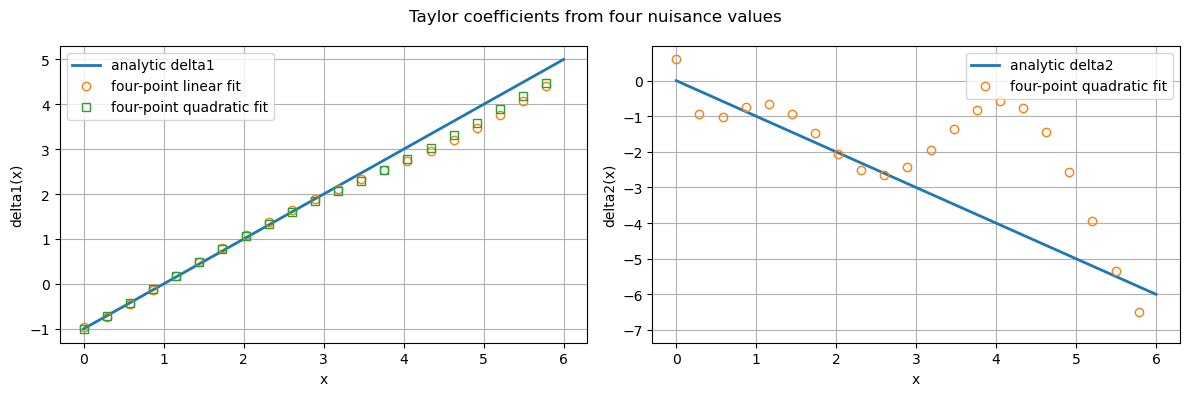

In [56]:
delta1_true = paper_exponential_delta1(x_flat)
delta2_true = paper_exponential_delta2(x_flat)

metrics = {
    "delta1_linear_rmse": float(
        np.sqrt(np.mean((delta1_linear_grid - delta1_true)**2))
    ),
    "delta1_quadratic_rmse": float(
        np.sqrt(np.mean((delta1_quadratic_grid - delta1_true)**2))
    ),
    "delta2_quadratic_rmse": float(
        np.sqrt(np.mean((delta2_quadratic_grid - delta2_true)**2))
    ),
    "delta1_linear_corr": float(
        np.corrcoef(delta1_linear_grid, delta1_true)[0, 1]
    ),
    "delta1_quadratic_corr": float(
        np.corrcoef(delta1_quadratic_grid, delta1_true)[0, 1]
    ),
    "delta2_quadratic_corr": float(
        np.corrcoef(delta2_quadratic_grid, delta2_true)[0, 1]
    ),
}
print(metrics)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x_flat, delta1_true, lw=2, label="analytic delta1")
axes[0].plot(
    x_flat, delta1_linear_grid, "o", fillstyle="none", markevery=12,
    label="four-point linear fit"
)
axes[0].plot(
    x_flat, delta1_quadratic_grid, "s", fillstyle="none", markevery=12,
    label="four-point quadratic fit"
)
axes[0].set_xlabel("x")
axes[0].set_ylabel("delta1(x)")
axes[0].legend()

axes[1].plot(x_flat, delta2_true, lw=2, label="analytic delta2")
axes[1].plot(
    x_flat, delta2_quadratic_grid, "o", fillstyle="none", markevery=12,
    label="four-point quadratic fit"
)
axes[1].set_xlabel("x")
axes[1].set_ylabel("delta2(x)")
axes[1].legend()

fig.suptitle("Taylor coefficients from four nuisance values")
fig.tight_layout();

## Fig. 3 Analogue

The left panel uses the four-point linear coefficient from $\{\pm0.05,\pm0.1\}$. The right panel is the best hybrid approximation: it uses the same linear coefficient together with the quadratic coefficient learned from $\{\pm0.2,\pm0.3\}$. Dashed curves are analytic, empty circles are the binned Falkon reconstruction, and filled squares with horizontal bin-width bars are the fourth-order binned monitor.

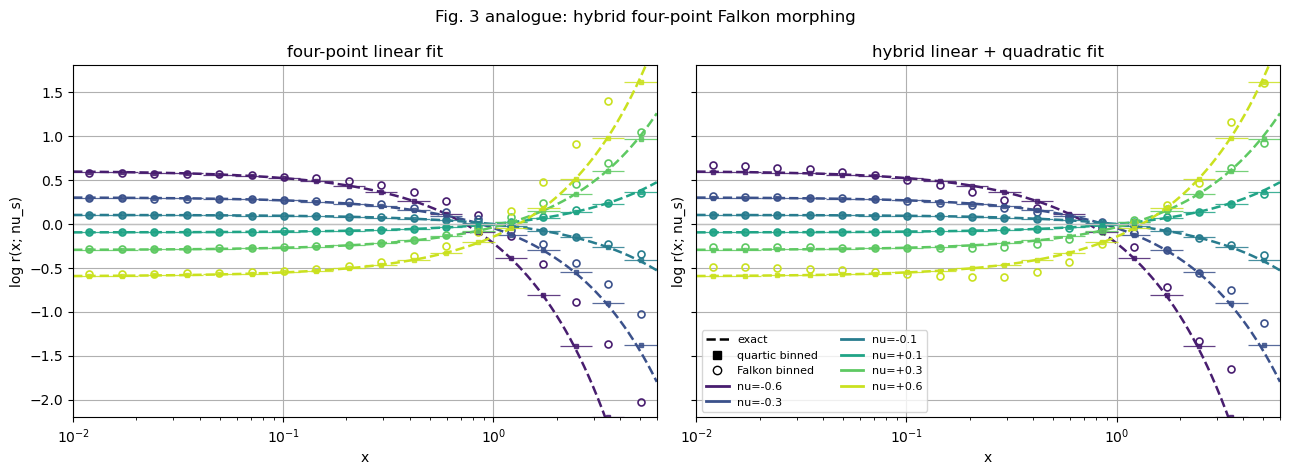

In [57]:
def build_quartic_bin_monitor(bin_edges, nuisance_values):
    """Fit a quartic nuisance response independently in every bin.

    :param bin_edges: Monotonic bin edges.
    :param nuisance_values: Nuisance scan used by the polynomial fit.
    :returns: Polynomial coefficients for every bin.
    """
    values = np.vstack([
        paper_exponential_bin_log_ratio(bin_edges, nu)
        for nu in nuisance_values
    ])
    return [
        np.polyfit(nuisance_values, values[:, index], 4)
        for index in range(values.shape[1])
    ]


def evaluate_bin_monitor(coefficients, nu):
    """Evaluate every bin polynomial at one nuisance value.

    :param coefficients: Sequence of polynomial coefficients.
    :param nu: Scalar nuisance value.
    :returns: Array containing one value per bin.
    """
    return np.asarray([np.polyval(coefficient, nu) for coefficient in coefficients])


def binned_log_ratio_from_reference(x_reference, log_ratio, bin_edges):
    """Integrate an event-level ratio over reference events in each bin.

    :param x_reference: Reference values with shape ``(n_events,)``.
    :param log_ratio: Event-level log-ratios with shape ``(n_events,)``.
    :param bin_edges: Monotonic bin edges.
    :returns: Bin-integrated log-ratio values.
    """
    x_reference = np.asarray(x_reference).reshape(-1)
    weights = np.exp(np.clip(np.asarray(log_ratio).reshape(-1), -30.0, 30.0))
    values = []
    for low, high in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (x_reference >= low) & (x_reference < high)
        values.append(np.log(np.mean(weights[mask])) if np.any(mask) else np.nan)
    return np.asarray(values)


nu_scan = np.linspace(-0.6, 0.6, 49)
fig3_nu_values = [-0.6, -0.3, -0.1, 0.1, 0.3, 0.6]
fig3_x_min = 1e-2
fig3_bin_edges = np.geomspace(fig3_x_min, x_plot_max, 19)
fig3_bin_centers = np.sqrt(fig3_bin_edges[:-1] * fig3_bin_edges[1:])
fig3_bin_xerr = np.vstack([
    fig3_bin_centers - fig3_bin_edges[:-1],
    fig3_bin_edges[1:] - fig3_bin_centers,
])
fig3_x_dense = np.geomspace(fig3_x_min, x_plot_max, 250)
fig3_bin_coefficients = build_quartic_bin_monitor(fig3_bin_edges, nu_scan)
colors = plt.cm.viridis(np.linspace(0.08, 0.92, len(fig3_nu_values)))

delta1_linear_central = linear_central_coefficients[0]
delta2_quadratic_central = quadratic_central_coefficients[1]
x_reference = x_central.reshape(-1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)

for nu, color in zip(fig3_nu_values, colors):
    exact = paper_exponential_log_ratio(fig3_x_dense, nu)
    linear_reference = nu * delta1_linear_central
    quadratic_reference = (
        nu * delta1_linear_central
        + 0.5 * nu**2 * delta2_quadratic_central
    )
    linear_binned = binned_log_ratio_from_reference(
        x_reference, linear_reference, fig3_bin_edges
    )
    quadratic_binned = binned_log_ratio_from_reference(
        x_reference, quadratic_reference, fig3_bin_edges
    )
    quartic_binned = evaluate_bin_monitor(fig3_bin_coefficients, nu)

    for ax, learned_binned in zip(axes, [linear_binned, quadratic_binned]):
        ax.plot(fig3_x_dense, exact, "--", color=color, lw=1.8)
        ax.errorbar(
            fig3_bin_centers,
            quartic_binned,
            xerr=fig3_bin_xerr,
            fmt="s",
            color=color,
            ms=3.5,
            elinewidth=0.9,
            capsize=0,
            linestyle="none",
            alpha=0.85,
        )
        ax.plot(
            fig3_bin_centers,
            learned_binned,
            "o",
            color=color,
            markerfacecolor="white",
            fillstyle="none",
            ms=5,
            mew=1.2,
        )

axes[0].set_title("four-point linear fit")
axes[1].set_title("hybrid linear + quadratic fit")
for ax in axes:
    ax.set_xscale("log")
    ax.set_xlim(fig3_x_min, x_plot_max)
    ax.set_ylim(-2.2, 1.8)
    ax.set_xlabel("x")
    ax.set_ylabel("log r(x; nu_s)")
    ax.axhline(0.0, color="0.75", lw=1)

style_handles = [
    Line2D([0], [0], color="black", ls="--", lw=1.8, label="exact"),
    Line2D(
        [0], [0], color="black", marker="s", markerfacecolor="black",
        ls="none", label="quartic binned"
    ),
    Line2D(
        [0], [0], color="black", marker="o", markerfacecolor="white",
        ls="none", label="Falkon binned"
    ),
]
nu_handles = [
    Line2D([0], [0], color=color, lw=2, label=f"nu={nu:+.1f}")
    for nu, color in zip(fig3_nu_values, colors)
]
axes[1].legend(
    handles=style_handles + nu_handles, fontsize=8, ncol=2, loc="lower left"
)
fig.suptitle("Fig. 3 analogue: hybrid four-point Falkon morphing")
fig.tight_layout();

## Build the Hybrid Quadratic Cache

The cache combines $\delta_1$ from $\{\pm0.05,\pm0.1\}$ with $\delta_2$ from $\{\pm0.2,\pm0.3\}$. The eight Falkon models are needed only while constructing these coefficients.

In [ ]:
cache = QuadraticLogRMorphingCache(
    delta1_ref=linear_central_coefficients[0],
    delta2_ref=quadratic_central_coefficients[1],
    delta1_data=linear_data_coefficients[0],
    delta2_data=quadratic_data_coefficients[1],
    metadata={
        "method": "hybrid_four_point_independent_falkon",
        "linear_nu_values": linear_nu_values.tolist(),
        "quadratic_nu_values": quadratic_nu_values.tolist(),
        "falkon_ratio_config": fit_config,
    },
)

{
    "reference_shape": cache.delta1_ref.shape,
    "data_shape": cache.delta1_data.shape,
    "nu_data_log_r_mean": float(np.mean(cache.log_r_data(nu_data))),
}